# Day 29: Customer Segmentation with K-Means

## Objective
Use K-Means Clustering to group customers based on purchasing behavior and identify meaningful customer segments.


### Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


### Step 2: Load Dataset
We use the popular Mall Customers dataset.


In [2]:
df = pd.read_csv("Mall_Customers.csv")
print(df.head())


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


### Step 3: Select Features

In [3]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]


### Step 4: Scale Data

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### Step 5: Find Optimal Clusters (Elbow Method)

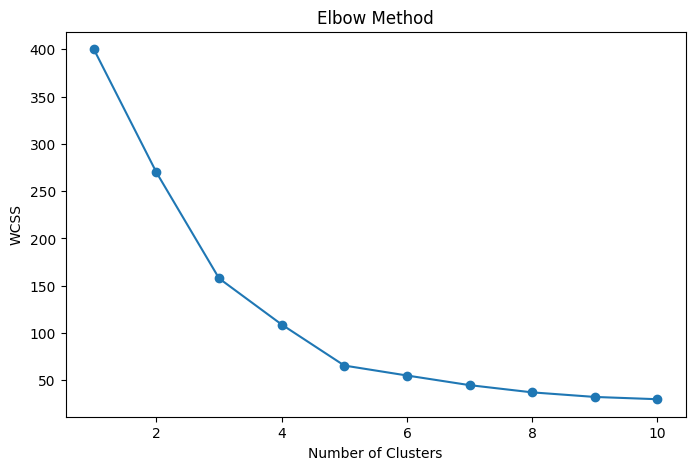

In [5]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


### Step 6: Apply K-Means

In [6]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters


### Step 7: Visualize Customer Segments

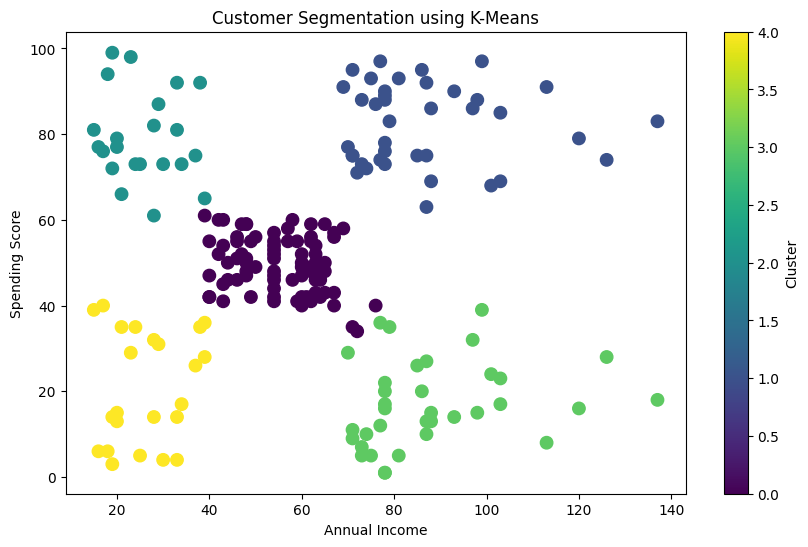

In [7]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis',
    s=80
)

plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customer Segmentation using K-Means')
plt.colorbar(label='Cluster')
plt.show()


### Step 8: Analyze Clusters

In [8]:
print(df.groupby('Cluster').mean(numeric_only=True))


         CustomerID        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                   
0         86.320988  42.716049           55.296296               49.518519
1        162.000000  32.692308           86.538462               82.128205
2         23.090909  25.272727           25.727273               79.363636
3        164.371429  41.114286           88.200000               17.114286
4         23.000000  45.217391           26.304348               20.913043
